# Notebook 06 — System Integration
**AGD 2026 | AI Workflow Engineer**

Goal: Connect reservoir outputs → surface system → LCOE model.
Runs the full scenario pipeline using `run_scenario()` and
saves results for the dashboard (Notebook 07).

In [1]:
import sys, warnings, yaml
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from pathlib import Path

with open("../config/settings.yaml") as f:
    CFG = yaml.safe_load(f)

PROC_DIR   = Path("..") / CFG["paths"]["data"]["processed"]
ECONOMIC   = Path("..") / CFG["paths"]["data"]["economic"]
EXTERNAL   = Path("..") / CFG["paths"]["data"]["external"]
REPORT_DIR = Path("..") / CFG["paths"]["outputs"]["reports"]
FIG_DIR    = Path("..") / CFG["paths"]["outputs"]["figures"]

from src.models.scenario_runner import (
    ScenarioInputs, run_scenario, run_standard_scenarios
)

ec = CFG["economics"]
print("Economic defaults loaded:")
for k, v in ec.items():
    print(f"  {k}: {v}")


Economic defaults loaded:
  discount_rate: 0.07
  lifetime_years: 30
  well_cost_eur_per_m: 3500
  surface_capex_eur: 3000000
  opex_fraction: 0.03
  reinj_temp_c: 40.0
  cop_heating: 4.0
  cop_cooling: 3.5
  fraction_for_cooling: 0.3


## 1. Load feasibility scores and ThermoGIS

In [2]:
# ── Load feasibility scores from Notebook 05 output ──
scores = pd.read_csv(REPORT_DIR / "feasibility_scores.csv")
print(f"Feasibility scores loaded: {scores.shape}")
print(scores[scores["scenario"]=="P50"].sort_values("score_total", ascending=False).to_string(index=False))

thermo_raw = pd.read_excel(EXTERNAL / "ThermoGIS Data.xlsx", sheet_name=None)

# Each sheet = one well, rows = properties, cols = P90/P50/P10
thermo = {}
for well_name, df_t in thermo_raw.items():
    df_t.columns = [str(c).strip() for c in df_t.columns]
    header_row = df_t[df_t.iloc[:, 0].astype(str).str.strip() == "Property"].index
    if len(header_row) == 0:
        continue
    hr = header_row[0]
    data = df_t.iloc[hr+1:].copy()
    data.columns = ["Property", "Unit", "P90", "P50", "P10"]
    data = data.dropna(subset=["Property"])
    data["Property"] = data["Property"].astype(str).str.strip()
    data = data.set_index("Property")
    thermo[well_name] = {
        prop: {
            "P90": float(row["P90"]) if str(row["P90"]) not in ("nan","") else 0.0,
            "P50": float(row["P50"]) if str(row["P50"]) not in ("nan","") else 0.0,
            "P10": float(row["P10"]) if str(row["P10"]) not in ("nan","") else 0.0,
        }
        for prop, row in data.iterrows()
    }

print("ThermoGIS loaded for wells:", list(thermo.keys()))
for well, props in thermo.items():
    flow  = props.get("Flow Rate",   {})
    temp  = props.get("Temperature", {})
    print(f"  {well}: flow P50={flow.get('P50')} m³/h, temp P50={temp.get('P50')}°C")


Feasibility scores loaded: (12, 19)
well_id scenario  score_total  verdict  score_flow  score_temp  score_perm  score_thick  score_dist  score_depth  flow_rate_m3h  temperature_c  permeability_md  thickness_m  distance_km     depth_m  heat_output_mwth  meets_heat_target  notes
 BLT-01      P50         62.9   VIABLE        15.8         9.6        20.0          6.6         8.0          3.0          105.0           77.0          752.100     198.8820     2.032828 2023.491000              4.51              False    NaN
 PKP-01      P50         42.6 MARGINAL         0.0        13.6        20.0          7.3         0.0          1.7            0.0           88.0          367.950     220.4000    22.716663 2640.700400              0.00              False    NaN
 EVD-01      P50         40.9 MARGINAL         0.0         7.9        20.0         10.0         0.0          3.0            0.0           72.0          519.120     408.9001    14.322698 1992.450288              0.00              False    

## 2. Inspect the LCOE Excel model

In [3]:
lcoe_path = ECONOMIC / "LCOE.xlsx"
xl = openpyxl.load_workbook(lcoe_path)
print(f"LCOE workbook sheets: {xl.sheetnames}")

# Print first few rows of Input_Output sheet if it exists
io_sheet = None
for s in xl.sheetnames:
    if "input" in s.lower() or "output" in s.lower() or "io" in s.lower():
        io_sheet = s
        break

if io_sheet:
    ws = xl[io_sheet]
    print(f"\n'{io_sheet}' sheet (first 30 non-empty rows):")
    count = 0
    for row in ws.iter_rows(values_only=True):
        if any(v is not None for v in row):
            print(row)
            count += 1
            if count >= 30:
                break


LCOE workbook sheets: ['Colofon', 'Input_Output', 'CFpower', 'CFheat']

'Input_Output' sheet (first 30 non-empty rows):
('=Colofon!C2', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None)
('=Colofon!C3', 'Geothermal Energy', None, None, 'Operational choice', None, 'heat', None, None, 'rock and fluid properties', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None)
(None, None, None, None, None, None, None, None, None, 'parameter', 'Value', 'Unit', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None)
(None, 'INPUTVARIABLES', 'used', 'Value', 'Unit', 'Comment', None, None, None, 'Cpwater', 4250, 'J/kg K', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None)
(None, 'Flowrate', 1, 50, 'L/s', 'total flow rate which is ac

## 3. Define scenarios from best well candidates

Using ThermoGIS P90/P50/P10 for BLT-01 (highest scorer).

In [4]:
# Helper to look up a parameter from feasibility_scores
def get_score_param(well_id, scenario, param):
    """Retrieve a parameter value from the scores DataFrame."""
    row = scores[(scores["well_id"] == well_id) & (scores["scenario"] == scenario)]
    if row.empty or param not in row.columns:
        return None
    val = row[param].iloc[0]
    return float(val) if pd.notna(val) else None

# Use best well from feasibility scores
p50_scores = scores[scores["scenario"] == "P50"].sort_values("score_total", ascending=False)
best_well = p50_scores.iloc[0]["well_id"]
print(f"Best well at P50: {best_well} (score: {p50_scores.iloc[0]['score_total']})")

t = thermo.get(best_well, {})

scenarios_def = {
    "P90 — Low":  ("P90", t.get("Flow Rate",{}).get("P90",0),
                          t.get("Temperature",{}).get("P90",60),
                          t.get("Top Depth",{}).get("P50",2000)),
    "P50 — Base": ("P50", t.get("Flow Rate",{}).get("P50",0),
                          t.get("Temperature",{}).get("P50",60),
                          t.get("Top Depth",{}).get("P50",2000)),
    "P10 — High": ("P10", t.get("Flow Rate",{}).get("P10",0),
                          t.get("Temperature",{}).get("P10",60),
                          t.get("Top Depth",{}).get("P50",2000)),
}

print("\nScenarios for integration run:")
for name, (sfx, flow, temp, depth) in scenarios_def.items():
    print(f"  {name}: flow={flow} m³/h, temp={temp}°C, depth={depth} m")


Best well at P50: BLT-01 (score: 62.9)

Scenarios for integration run:
  P90 — Low: flow=17.0 m³/h, temp=77.0°C, depth=1837.0 m
  P50 — Base: flow=105.0 m³/h, temp=77.0°C, depth=1837.0 m
  P10 — High: flow=469.0 m³/h, temp=77.0°C, depth=1837.0 m


## 4. Run full integration via `run_scenario()`

In [5]:
all_results = []

for scenario_name, (sfx, flow, temp, depth) in scenarios_def.items():
    if flow is None or temp is None:
        print(f"  Skipping {scenario_name} — missing data")
        continue

    inp = ScenarioInputs(
        scenario_name        = scenario_name,
        flow_rate_ls         = flow / 3.6,      # m³/h → L/s
        prod_temp_c          = temp,
        reinj_temp_c         = ec["reinj_temp_c"],
        well_depth_m         = depth or 2000.0,
        n_prod_wells         = 1,
        n_inj_wells          = 1,
        cop_heating          = ec["cop_heating"],
        cop_cooling          = ec["cop_cooling"],
        fraction_for_cooling = ec["fraction_for_cooling"],
        lifetime_years       = ec["lifetime_years"],
        discount_rate        = ec["discount_rate"],
        well_cost_eur_per_m  = ec["well_cost_eur_per_m"],
        surface_capex_eur    = ec["surface_capex_eur"],
        opex_fraction        = ec["opex_fraction"],
    )

    out = run_scenario(inp)

    all_results.append({
        "Scenario":               out.scenario_name,
        "Well":                   best_well,
        "Flow Rate (m³/h)":       round(flow, 1),
        "Prod Temp (°C)":         round(temp, 1),
        "Heat Output (MWth)":     out.heat_output_mwth,
        "Cooling Output (MWth)":  out.cooling_output_mwth,
        "Gross Geo Power (kW)":   out.gross_thermal_kw,
        "CAPEX (M€)":             round(out.capex_eur / 1e6, 2),
        "Annual OPEX (k€)":       round(out.annual_opex_eur / 1e3, 1),
        "LCoE Heat (€/GJ)":       out.lcoe_heating_eur_gj,
        "LCoE Blended (€/GJ)":    out.lcoe_blended_eur_gj,
        "NPV (M€)":               round(out.npv_eur / 1e6, 2),
        "Payback (yrs)":          out.simple_payback_years,
        "Meets Heat Target":      out.meets_heat_target,
        "Meets Cooling Target":   out.meets_cooling_target,
    })
    print(f"\n{scenario_name}:")
    print(f"  Heat: {out.heat_output_mwth} MWth | Cooling: {out.cooling_output_mwth} MWth")
    print(f"  CAPEX: €{out.capex_eur/1e6:.2f}M | LCoE heat: €{out.lcoe_heating_eur_gj:.1f}/GJ")
    print(f"  NPV: €{out.npv_eur/1e6:.2f}M | Payback: {out.simple_payback_years} yrs")
    print(f"  Heat target met: {out.meets_heat_target} | Cooling target met: {out.meets_cooling_target}")

results_df = pd.DataFrame(all_results)
print("\n=== SCENARIO SUMMARY ===")
print(results_df.to_string(index=False))



P90 — Low:
  Heat: 0.682 MWth | Cooling: 0.767 MWth
  CAPEX: €15.86M | LCoE heat: €85.8/GJ
  NPV: €-12.41M | Payback: 57.1 yrs
  Heat target met: False | Cooling target met: False

P50 — Base:
  Heat: 4.21 MWth | Cooling: 4.736 MWth
  CAPEX: €15.86M | LCoE heat: €13.9/GJ
  NPV: €35.95M | Payback: 3.8 yrs
  Heat target met: False | Cooling target met: False

P10 — High:
  Heat: 18.806 MWth | Cooling: 21.156 MWth
  CAPEX: €15.86M | LCoE heat: €3.1/GJ
  NPV: €236.04M | Payback: 0.8 yrs
  Heat target met: True | Cooling target met: True

=== SCENARIO SUMMARY ===
  Scenario   Well  Flow Rate (m³/h)  Prod Temp (°C)  Heat Output (MWth)  Cooling Output (MWth)  Gross Geo Power (kW)  CAPEX (M€)  Annual OPEX (k€)  LCoE Heat (€/GJ)  LCoE Blended (€/GJ)  NPV (M€)  Payback (yrs)  Meets Heat Target  Meets Cooling Target
 P90 — Low BLT-01              17.0            77.0               0.682                  0.767                 730.3       15.86             475.8             85.83                40

## 5. Sensitivity analysis — which input moves LCoE most?

In [6]:
# Base case inputs (P50)
base_flow  = get_score_param(best_well, "P50", "flow_rate_m3h") or 100.0
base_temp  = get_score_param(best_well, "P50", "temperature_c") or 75.0
base_depth = get_score_param(best_well, "P50", "depth_m") or 2000.0

base_inp = ScenarioInputs(
    scenario_name="Base",
    flow_rate_ls=base_flow / 3.6,
    prod_temp_c=base_temp,
    reinj_temp_c=ec["reinj_temp_c"],
    well_depth_m=base_depth,
    cop_heating=ec["cop_heating"],
    cop_cooling=ec["cop_cooling"],
    fraction_for_cooling=ec["fraction_for_cooling"],
    lifetime_years=ec["lifetime_years"],
    discount_rate=ec["discount_rate"],
    well_cost_eur_per_m=ec["well_cost_eur_per_m"],
    surface_capex_eur=ec["surface_capex_eur"],
    opex_fraction=ec["opex_fraction"],
)
base_lcoe = run_scenario(base_inp).lcoe_blended_eur_gj

# Vary each input ±20% and measure LCoE change
sensitivity_params = {
    "Flow Rate":        ("flow_rate_ls",       base_inp.flow_rate_ls,       0.20),
    "Prod Temperature": ("prod_temp_c",         base_inp.prod_temp_c,        0.10),
    "Well Depth":       ("well_depth_m",        base_inp.well_depth_m,       0.20),
    "COP (Heating)":    ("cop_heating",         base_inp.cop_heating,        0.20),
    "Discount Rate":    ("discount_rate",       base_inp.discount_rate,      0.20),
    "Surface CAPEX":    ("surface_capex_eur",   base_inp.surface_capex_eur,  0.20),
    "Well Cost/m":      ("well_cost_eur_per_m", base_inp.well_cost_eur_per_m,0.20),
}

sensitivity = []
for label, (attr, base_val, pct) in sensitivity_params.items():
    for direction, factor in [("Low (-20%)", 1 - pct), ("High (+20%)", 1 + pct)]:
        inp = ScenarioInputs(**{
            **vars(base_inp),
            attr: base_val * factor,
            "scenario_name": f"{label} {direction}",
        })
        out = run_scenario(inp)
        sensitivity.append({
            "Parameter": label,
            "Direction": direction,
            "LCoE (€/GJ)": out.lcoe_blended_eur_gj,
            "Delta vs Base": round(out.lcoe_blended_eur_gj - base_lcoe, 2),
        })

sens_df = pd.DataFrame(sensitivity)
print(f"Base LCoE: €{base_lcoe:.2f}/GJ")
print(sens_df.to_string(index=False))


Base LCoE: €7.08/GJ
       Parameter   Direction  LCoE (€/GJ)  Delta vs Base
       Flow Rate  Low (-20%)         8.85           1.77
       Flow Rate High (+20%)         5.90          -1.18
Prod Temperature  Low (-20%)         8.94           1.86
Prod Temperature High (+20%)         5.86          -1.22
      Well Depth  Low (-20%)         5.91          -1.17
      Well Depth High (+20%)         8.25           1.17
   COP (Heating)  Low (-20%)         6.79          -0.29
   COP (Heating) High (+20%)         7.26           0.18
   Discount Rate  Low (-20%)         6.38          -0.70
   Discount Rate High (+20%)         7.83           0.75
   Surface CAPEX  Low (-20%)         6.83          -0.25
   Surface CAPEX High (+20%)         7.33           0.25
     Well Cost/m  Low (-20%)         5.91          -1.17
     Well Cost/m High (+20%)         8.25           1.17


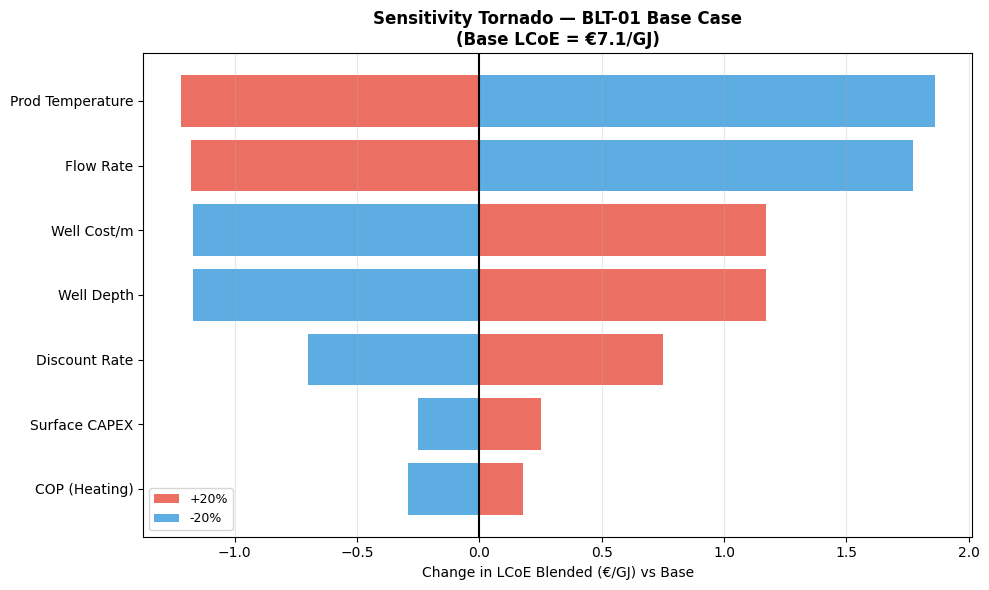

Saved: 06_sensitivity_tornado.png


In [7]:
# Tornado chart
fig, ax = plt.subplots(figsize=(10, 6))

params = list(sensitivity_params.keys())
low_deltas  = [sens_df[(sens_df["Parameter"]==p) & (sens_df["Direction"].str.contains("Low"))]["Delta vs Base"].iloc[0]
               for p in params]
high_deltas = [sens_df[(sens_df["Parameter"]==p) & (sens_df["Direction"].str.contains("High"))]["Delta vs Base"].iloc[0]
               for p in params]

# Sort by total swing
swings = [abs(h) + abs(l) for h, l in zip(high_deltas, low_deltas)]
order = np.argsort(swings)

params_sorted     = [params[i] for i in order]
low_sorted        = [low_deltas[i] for i in order]
high_sorted       = [high_deltas[i] for i in order]

y = np.arange(len(params_sorted))
ax.barh(y, high_sorted, left=0, color="#e74c3c", alpha=0.8, label="+20%")
ax.barh(y, low_sorted,  left=0, color="#3498db", alpha=0.8, label="-20%")
ax.axvline(0, color="black", lw=1.5)
ax.set_yticks(y)
ax.set_yticklabels(params_sorted, fontsize=10)
ax.set_xlabel("Change in LCoE Blended (€/GJ) vs Base", fontsize=10)
ax.set_title(f"Sensitivity Tornado — {best_well} Base Case\n(Base LCoE = €{base_lcoe:.1f}/GJ)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_sensitivity_tornado.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 06_sensitivity_tornado.png")


## 6. Save scenario results

In [8]:
out_path = REPORT_DIR / "scenario_results.csv"
results_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"\nReady for Notebook 07 — Scenario Dashboard")


Saved: ..\outputs\reports\scenario_results.csv

Ready for Notebook 07 — Scenario Dashboard
